# Play Store App Review Analysis


# **Introduction & Purpose**

The Google Play Store is the hub of the Android world — a dynamic platform where millions of apps compete for downloads, attention, and user love 💡📱. But in this crowded space, not every app makes it.

So...
What separates a top-rated app from the rest?
Which features truly drive installs and engagement?

🔍 This project takes a deep dive into Play Store app data to answer these questions. We explore patterns in ratings, pricing, categories, sizes, user reviews, and more — all to understand the anatomy of a successful app.

🧹 First, we clean the messy data — removing duplicates, handling missing values, and fixing inconsistencies.
📊 Then, we use powerful tools like pandas, numpy, matplotlib, and seaborn to analyze and visualize trends.
💬 We even look at user reviews to understand the voice of the users and what they really care about.

👉 Goal: Turn raw data into real insight — guiding developers to make smarter, user-focused apps.

🔘 Let’s decode what makes an app thrive.

In [1]:
# Datasets used:
# - Play Store Data.csv — App metadata (ratings, installs, category, etc.)
# - User Reviews.csv — User review text and sentiment scores
DATASET_PATH = ""  # CSVs should be in the same folder as this notebook

# **Problem Statement**


The Google Play Store ecosystem contains millions of apps, yet only a subset achieves high user engagement and favorable ratings. Developers lack clear, data-driven insights into which app attributes most strongly impact success metrics.

Using two datasets — one detailing app metadata (category, rating, size, installs, price, content rating) and another comprising user review texts — this project aims to:

🔎 Perform feature analysis to identify key drivers of app ratings and install counts

🧠 Apply sentiment analysis on user reviews to quantify feedback and satisfaction levels

📈 Explore correlations and patterns between app characteristics and user sentiments

🛠️ Provide actionable insights for developers to optimize app design, pricing, and marketing strategies based on data

#### **Business Objective**

The main goal is to leverage app metadata and user review data to extract actionable insights that help developers:

* Optimize app features and pricing strategies to boost ratings and installs

* Understand user sentiment trends to improve app quality and engagement

* Identify high-potential app categories and content ratings for targeted development

* Enable data-driven decisions that increase app visibility and market success on the Google Play Store



# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

### Dataset Loading

In [3]:
# Data already loaded above

### Dataset First View

In [4]:
# Dataset First Look
play_store_data = pd.read_csv(DATASET_PATH + "Play Store Data.csv")
play_store_data_head_tail = pd.concat([play_store_data.head(), play_store_data.tail()])
play_store_data_head_tail

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device
10840,iHoroscope - 2018 Daily Horoscope & Astrology,LIFESTYLE,4.5,398307,19M,"10,000,000+",Free,0,Everyone,Lifestyle,"July 25, 2018",Varies with device,Varies with device


In [5]:
play_store_data.shape

(10841, 13)

In [6]:
# First look of User Reviews dataset
user_reviews_data = pd.read_csv(DATASET_PATH + "User Reviews.csv")
user_reviews_data_head_tail = pd.concat([user_reviews_data.head(), user_reviews_data.tail()])
user_reviews_data_head_tail

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000
64290,Houzz Interior Design Ideas,NaN,NaN,NaN,NaN
64291,Houzz Interior Design Ideas,NaN,NaN,NaN,NaN
64292,Houzz Interior Design Ideas,NaN,NaN,NaN,NaN
64293,Houzz Interior Design Ideas,NaN,NaN,NaN,NaN
64294,Houzz Interior Design Ideas,NaN,NaN,NaN,NaN


In [7]:
user_reviews_data.shape

(64295, 5)

### Dataset Rows & Columns count

In [8]:
# Calculating Rows and Columns of both datasets
def count_rows_columns(data):
    return data.shape

rows1, cols1 = count_rows_columns(play_store_data)
rows2, cols2 = count_rows_columns(user_reviews_data)

print(f'Play Store Data - Rows: {rows1}, Columns: {cols1}')
print(f'User Reviews Data - Rows: {rows2}, Columns: {cols2}')

Play Store Data - Rows: 10841, Columns: 13
User Reviews Data - Rows: 64295, Columns: 5


### Dataset Information

In [9]:
# Dataset Info
play_store_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [10]:
# No. of Categories
play_store_data['Category'].nunique()

34

In [11]:
# No. of Genres
play_store_data['Genres'].nunique()

120

In [12]:
# Checking unique Genres in Category
play_store_data.groupby('Category')['Genres'].nunique()

Category
1.9                     1
ART_AND_DESIGN          4
AUTO_AND_VEHICLES       1
BEAUTY                  1
BOOKS_AND_REFERENCE     1
BUSINESS                1
COMICS                  2
COMMUNICATION           1
DATING                  1
EDUCATION               7
ENTERTAINMENT           4
EVENTS                  1
FAMILY                 73
FINANCE                 1
FOOD_AND_DRINK          1
GAME                   24
HEALTH_AND_FITNESS      1
HOUSE_AND_HOME          1
LIBRARIES_AND_DEMO      1
LIFESTYLE               2
MAPS_AND_NAVIGATION     1
MEDICAL                 1
NEWS_AND_MAGAZINES      1
PARENTING               4
PERSONALIZATION         1
PHOTOGRAPHY             1
PRODUCTIVITY            1
SHOPPING                1
SOCIAL                  1
SPORTS                  1
TOOLS                   2
TRAVEL_AND_LOCAL        2
VIDEO_PLAYERS           3
WEATHER                 1
Name: Genres, dtype: int64

#### Duplicate Values

In [13]:
# Play Store Data Duplicate Value Count
len(play_store_data[play_store_data.duplicated()])

483

In [14]:
# No. of Duplicate Values in Columns
for col in play_store_data.columns:
    dup_count = play_store_data[col].duplicated(keep=False).sum()
    print(f"\n{col}: {dup_count} duplicate values")


App: 1979 duplicate values

Category: 10840 duplicate values

Rating: 10839 duplicate values

Reviews: 5855 duplicate values

Size: 10595 duplicate values

Installs: 10839 duplicate values

Type: 10839 duplicate values

Price: 10787 duplicate values

Content Rating: 10840 duplicate values

Genres: 10817 duplicate values

Last Updated: 10417 duplicate values

Current Ver: 9030 duplicate values

Android Ver: 10836 duplicate values


In [15]:
# User Reviews data Duplicate Value Count
len(user_reviews_data[user_reviews_data.duplicated()])

33616

In [16]:
# No. of Duplicate Values in Columns
for col in user_reviews_data.columns:
    dup_count = user_reviews_data[col].duplicated(keep=False).sum()
    print(f"\n{col}: {dup_count} duplicate values")


App: 64295 duplicate values

Translated_Review: 41702 duplicate values

Sentiment: 64295 duplicate values

Sentiment_Polarity: 61464 duplicate values

Sentiment_Subjectivity: 62022 duplicate values


#### Missing Values/Null Values

In [17]:
# Missing Values/Null Values Count in Play Store Data
print(play_store_data.isnull().sum())

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64


In [18]:
# Missing Values/Null Values count in User Reviews Data
print(user_reviews_data.isnull().sum())

App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64


### What did you know about your dataset?

* Play Store dataset contains detailed info on each app — like its category, rating, size, number of installs, price, content rating, and more. This helps us understand the app’s features and popularity.

* User Reviews dataset holds user reviews, which give a voice to the users — showing their opinions, satisfaction, and issues through text feedback.

* Together, these datasets offer a rich mix of quantitative (numbers, ratings) and qualitative (reviews, sentiments) data, perfect for analyzing what makes an app successful and how users really feel about it.

## ***2. Understanding Your Variables***

In [19]:
# Dataset Columns and Rows
print(play_store_data.columns)

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')


In [20]:
print(user_reviews_data.columns)

Index(['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity',
       'Sentiment_Subjectivity'],
      dtype='object')


In [21]:
# Dataset Describe
play_store_data.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [22]:
user_reviews_data.describe()

,Sentiment_Polarity,Sentiment_Subjectivity
count,37432.000000,37432.000000
mean,0.182146,0.492704
std,0.351301,0.259949
min,-1.000000,0.000000
25%,0.000000,0.357143
50%,0.150000,0.514286
75%,0.400000,0.650000
max,1.000000,1.000000


### Variables Description

####**Play Store App Dataset Columns:**

* App: Name of the app

* Category: App genre/type (e.g., Games, Education)

* Rating: Average user rating (numeric)

* Reviews: Number of user reviews (count)

* Size: App size (MB or KB)

* Installs: Number of times the app was installed

* Type: Free or Paid app

* Price: Cost (if paid)

* Content Rating: Age suitability (e.g., Everyone, Teen)

* Genres: More detailed app category info

* Last Updated: Date of last app update

* Current Ver: Current app version

* Android Ver: Minimum Android version required

#### **User Reviews Dataset:**

* App: App name (to link reviews)

* Translated_Review: User review text (translated if needed)

* Sentiment: Review sentiment category (e.g., Positive, Negative, Neutral)

* Sentiment_Polarity: Numeric score showing positivity/negativity of review

* Sentiment_Subjectivity: Numeric score indicating if review is opinionated (subjective) or factual (objective)

### Check Unique Values for each variable.

In [23]:
# Check Unique Values for each variable.
for column in play_store_data.columns:
  print(f"No. of unique values in {column} is {play_store_data[column].nunique()}.")

No. of unique values in App is 9660.
No. of unique values in Category is 34.
No. of unique values in Rating is 40.
No. of unique values in Reviews is 6002.
No. of unique values in Size is 462.
No. of unique values in Installs is 22.
No. of unique values in Type is 3.
No. of unique values in Price is 93.
No. of unique values in Content Rating is 6.
No. of unique values in Genres is 120.
No. of unique values in Last Updated is 1378.
No. of unique values in Current Ver is 2832.
No. of unique values in Android Ver is 33.


In [24]:
for column in user_reviews_data:
  print(f"No. of unique values in {column} is {user_reviews_data[column].nunique()}")

No. of unique values in App is 1074


No. of unique values in Translated_Review is 27994
No. of unique values in Sentiment is 3
No. of unique values in Sentiment_Polarity is 5410
No. of unique values in Sentiment_Subjectivity is 4474


## 3. ***Data Wrangling***

### **Data Cleaning**

### **Handling the NaN values in the dataset**

#### For User Reviews dataset

In [25]:
# This table will give the required info of the data like Datatype, no. of not null values and null values, null % and no. of unique values in each column
table = pd.DataFrame(index = user_reviews_data.columns)
table["Datatype"] = user_reviews_data.dtypes
table["Not Null"] = user_reviews_data.count()
table["Null"] = user_reviews_data.isnull().sum()
table["Null %"] = (user_reviews_data.isnull().sum()/len(user_reviews_data))*100
table["Unique Values"] = user_reviews_data.nunique()
table

,Datatype,Not Null,Null,Null %,Unique Values
App,object,64295,0,0.000000,1074
Translated_Review,object,37427,26868,41.788631,27994
Sentiment,object,37432,26863,41.780854,3
Sentiment_Polarity,float64,37432,26863,41.780854,5410
Sentiment_Subjectivity,float64,37432,26863,41.780854,4474


**Findings**:
* Significant missing data (~42%) in all sentiment-related columns

* App column is clean and can be used as a reliable key

* High uniqueness in Translated_Review implies mostly unique user reviews

The missing values in the Translated_Review, Sentiment, Sentiment_Polarity, and Sentiment_Subjectivity columns exist because many users did not provide any review. Since these columns are interrelated—where sentiment analysis can only be performed if a review is present—the absence of one logically leads to the absence of the others. Therefore, these null entries do not contribute any meaningful data for analysis. Dropping these rows, despite them being about 42% of the dataset, is a valid step as it ensures the dataset remains clean and focused on actual user feedback, without introducing any bias or data manipulation.

In [26]:
# These columns are interdependent, so missing one usually means all are missing
user_reviews_data.dropna(subset=['Translated_Review', 'Sentiment', 'Sentiment_Polarity', 'Sentiment_Subjectivity'], inplace=True)
user_reviews_data.isnull().sum()

App                       0
Translated_Review         0
Sentiment                 0
Sentiment_Polarity        0
Sentiment_Subjectivity    0
dtype: int64

#### For Play Store dataset

In [27]:
# This table will give the required info of the data like Datatype, no. of not null values and null values, null % and no. of unique values in each column
table = pd.DataFrame(index = play_store_data.columns)
table["Datatype"] = play_store_data.dtypes
table["Not Null"] = play_store_data.count()
table["Null"] = play_store_data.isnull().sum()
table["Null %"] = (play_store_data.isnull().sum()/len(play_store_data))*100
table["Unique Values"] = play_store_data.nunique()
table

,Datatype,Not Null,Null,Null %,Unique Values
App,object,10841,0,0.000000,9660
Category,object,10841,0,0.000000,34
Rating,float64,9367,1474,13.596532,40
Reviews,object,10841,0,0.000000,6002
Size,object,10841,0,0.000000,462
Installs,object,10841,0,0.000000,22
Type,object,10840,1,0.009224,3
Price,object,10841,0,0.000000,93
Content Rating,object,10840,1,0.009224,6
Genres,object,10841,0,0.000000,120


**Findings**:
* Rating column has 13.59% null values (1,474 rows), which may affect average rating analysis.
* Minor nulls found in:
Type: 1 missing
Content Rating: 1 missing
Current Ver: 8 missing
Android Ver: 3 missing
* Null percentages in these columns are less than 1%, safe to drop or fill.

**Current Ver and Android Ver** :
* The columns Current Ver and Android Ver have 8 and 3 missing values respectively, which is a very small fraction of the dataset.
* These columns are not critical for our analysis or business insights, and they do not contribute significantly to visualizations or decision-making.
* Since the missing values cannot be imputed reliably due to the lack of related context, and dropping the rows could result in unnecessary data loss, we choose to leave these null values as they are.
* Their presence will not impact the analysis, as these columns will not be used in any meaningful way during exploration or modeling.

First, we handle column with fewer NaN values. These can be filled using mean, median, or mode, or dropped if there's a valid reason.

##### **`1). Type: There is 1 NaN value in this column.`**

In [28]:
# Rows containing NaN values in the Rating column
play_store_data[play_store_data['Type'].isnull()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
9148,Command & Conquer: Rivals,FAMILY,NaN,0,Varies with device,0,NaN,0,Everyone 10+,Strategy,"June 28, 2018",Varies with device,Varies with device


It has shown that there is 1 NaN value, dropping it likely won't significantly affect the analysis.

In [29]:
play_store_data.dropna(subset=['Type'], inplace=True)
play_store_data[play_store_data['Type'].isnull()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


##### **`2). Content Rating: There is 1 NaN value in this column.`**

In [30]:
play_store_data[play_store_data['Content Rating'].isnull()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


It also has shown that there is 1 NaN value, dropping it likely won't significantly affect the analysis.

In [31]:
play_store_data.dropna(subset=['Content Rating'], inplace=True)
play_store_data[play_store_data['Content Rating'].isnull()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


##### **`2). Rating: There are 1474 NaN values in this column.`**

In [32]:
play_store_data[play_store_data['Rating'].isnull()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
23,Mcqueen Coloring pages,ART_AND_DESIGN,NaN,61,7.0M,"100,000+",Free,0,Everyone,Art & Design;Action & Adventure,"March 7, 2018",1.0.0,4.1 and up
113,Wrinkles and rejuvenation,BEAUTY,NaN,182,5.7M,"100,000+",Free,0,Everyone 10+,Beauty,"September 20, 2017",8.0,3.0 and up
123,Manicure - nail design,BEAUTY,NaN,119,3.7M,"50,000+",Free,0,Everyone,Beauty,"July 23, 2018",1.3,4.1 and up
126,Skin Care and Natural Beauty,BEAUTY,NaN,654,7.4M,"100,000+",Free,0,Teen,Beauty,"July 17, 2018",1.15,4.1 and up
129,"Secrets of beauty, youth and health",BEAUTY,NaN,77,2.9M,"10,000+",Free,0,Mature 17+,Beauty,"August 8, 2017",2.0,2.3 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10824,Cardio-FR,MEDICAL,NaN,67,82M,"10,000+",Free,0,Everyone,Medical,"July 31, 2018",2.2.2,4.4 and up
10825,Naruto & Boruto FR,SOCIAL,NaN,7,7.7M,100+,Free,0,Teen,Social,"February 2, 2018",1.0,4.0 and up
10831,payermonstationnement.fr,MAPS_AND_NAVIGATION,NaN,38,9.8M,"5,000+",Free,0,Everyone,Maps & Navigation,"June 13, 2018",2.0.148.0,4.0 and up
10835,FR Forms,BUSINESS,NaN,0,9.6M,10+,Free,0,Everyone,Business,"September 29, 2016",1.1.5,4.0 and up


* The Rating column has 1,474 missing values, accounting for approximately 13.59% of the dataset.
* Dropping these rows would result in a significant loss of valuable information and could manipulate the dataset by removing diverse user perspectives.
* Imputing with the mean or median could introduce bias and distort the overall rating distribution.
* Therefore, to maintain neutrality and retain data integrity, we choose to fill these missing values with 1, representing a neutral or balanced user opinion.

In [33]:
play_store_data['Rating'] = play_store_data['Rating'].fillna(1)
play_store_data[play_store_data['Rating'].isnull()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


In [34]:
play_store_data.isna().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       8
Android Ver       2
dtype: int64

### **Handling duplicates values**

In [35]:
# Inspecting the duplicated rows in Play Store Data
duplicates= play_store_data[play_store_data.duplicated(keep=False)]
print(duplicates)

                                                   App             Category  \
164                                       Ebook Reader  BOOKS_AND_REFERENCE   
192                      Docs To Go™ Free Office Suite             BUSINESS   
193                                 Google My Business             BUSINESS   
204                                                Box             BUSINESS   
213                                ZOOM Cloud Meetings             BUSINESS   
...                                                ...                  ...   
8643                    Wunderlist: To-Do List & Tasks         PRODUCTIVITY   
8654   TickTick: To Do List with Reminder, Day Planner         PRODUCTIVITY   
8658                           ColorNote Notepad Notes         PRODUCTIVITY   
10049        Airway Ex - Intubate. Anesthetize. Train.              MEDICAL   
10768                                             AAFP              MEDICAL   

       Rating  Reviews                Size      Ins

This reveals a significant presence of exact duplicate rows in the dataset, indicating a need for data cleaning to ensure accurate and reliable insights during further exploration.


In [36]:
play_store_data = play_store_data.drop_duplicates().reset_index(drop=True)

In [37]:
play_store_data.duplicated().sum()

np.int64(0)

In [38]:
# Inspecting and Removing duplicated rows in User Reviews Data
user_reviews_data.duplicated().sum()

np.int64(7735)

In [39]:
# Dropping duplicated Rows
user_reviews_data = user_reviews_data.drop_duplicates().reset_index(drop=True)

In [40]:
user_reviews_data.duplicated().sum()

np.int64(0)

We have successfully handled all the exact duplicate rows in Play Store Data and User Reviews Dataset.

In [41]:
# The resultant size after droping the duplicate rows in both the dataset
print(play_store_data.shape)
print(user_reviews_data.shape)

(10356, 13)
(29692, 5)


### **Handling the datatypes**

#### **`1). Converting the datatype of values in the Reviews column from string to int.`**

In [42]:
# Convert the datatype from object to int
play_store_data['Reviews'] = play_store_data['Reviews'].astype(int)
play_store_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10356 entries, 0 to 10355
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10356 non-null  object 
 1   Category        10356 non-null  object 
 2   Rating          10356 non-null  float64
 3   Reviews         10356 non-null  int64  
 4   Size            10356 non-null  object 
 5   Installs        10356 non-null  object 
 6   Type            10356 non-null  object 
 7   Price           10356 non-null  object 
 8   Content Rating  10356 non-null  object 
 9   Genres          10356 non-null  object 
 10  Last Updated    10356 non-null  object 
 11  Current Ver     10348 non-null  object 
 12  Android Ver     10354 non-null  object 
dtypes: float64(1), int64(1), object(11)
memory usage: 1.0+ MB


#### **`2). Converting the values in Size column to a same unit of measure i.e. MB.`**

In [43]:
# Check unique values in a particular Size column
play_store_data['Size'].value_counts()

Size
Varies with device    1525
11M                    188
13M                    186
12M                    186
14M                    182
                      ... 
23k                      1
981k                     1
784k                     1
280k                     1
24k                      1
Name: count, Length: 461, dtype: int64

The Size column contains values in mixed units — ‘M’ for MB and ‘k’ for KB. To simplify analysis, we'll convert all sizes to a single unit: MB.
Since 1 MB = 1024 KB, any value in KB will be divided by 1024 to convert it to MB.

Also, there are some inconsistent entries 'Varies with device' that needs to be cleaned.


In [44]:
# Replace 'Varies with device' with NaN to handle inconsistent entries
play_store_data['Size'] = play_store_data['Size'].replace('Varies with device', np.nan)

# Convert all sizes to MB
play_store_data['Size'] = play_store_data['Size'].apply(
    lambda x: float(x[:-1]) if 'M' in str(x)        # If value ends with 'M' (MB), remove 'M' and convert to float
    else round(float(x[:-1]) / 1024, 4) if 'k' in str(x)  # If value ends with 'k' (KB), convert to MB by dividing by 1024
    else x                                          # Leave as is (NaN or already processed)
)
play_store_data

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10351,Sya9a Maroc - FR,FAMILY,4.5,38,53.0,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10352,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10353,Parkinson Exercices FR,MEDICAL,1.0,3,9.5,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10354,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,NaN,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


**Visualization of distribution of Size using Histogram and detecting the outliers using Boxplot**

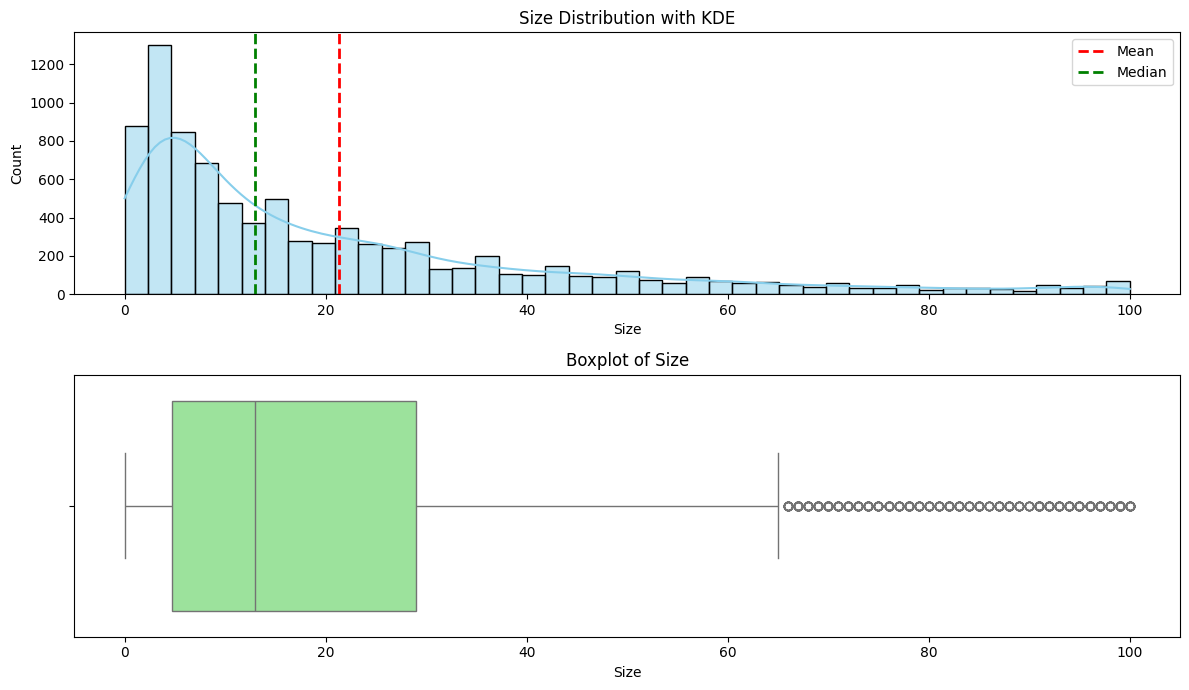

In [45]:
fig, ax = plt.subplots(2, 1, figsize=(12, 7))  # Create figure and axes
size_mean = play_store_data['Size'].mean()
size_median = play_store_data['Size'].median()

# Histogram + KDE
sns.histplot(play_store_data['Size'], kde=True, color='skyblue', ax=ax[0])  # Plot on ax[0]
ax[0].set_title('Size Distribution with KDE')
ax[0].axvline(size_mean, color='red', linestyle='dashed', linewidth=2, label='Mean')  # Add mean line
ax[0].axvline(size_median, color='green', linestyle='dashed', linewidth=2, label='Median')  # Add median line
ax[0].legend()

# Boxplot
sns.boxplot(x=play_store_data['Size'], color='lightgreen', ax=ax[1])  # Plot on ax[1]
ax[1].set_title('Boxplot of Size')

plt.tight_layout()
plt.show()

Now, the Size column contains a large number of NaN values due to the removal of "Varies with device". Dropping these rows would lead to significant data loss, so we need to impute them. Since app sizes vary widely across categories and the column is right-skewed, imputing with the median size within each app category is more appropriate than using the overall mean or median. This ensures that missing values are replaced with realistic sizes relative to their category.

In [46]:
play_store_data['Size'] = play_store_data.groupby('Category')['Size'].transform(lambda x: x.fillna(x.median()))
play_store_data

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.00,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.00,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.70,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.00,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.80,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10351,Sya9a Maroc - FR,FAMILY,4.5,38,53.00,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10352,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.60,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10353,Parkinson Exercices FR,MEDICAL,1.0,3,9.50,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10354,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,7.35,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


We have successfully manipulated all the entries in the Size column to a single unit of measure (MB) and the datatype from string to float.

#### **`3). Converting the datatype of values in Installs column `**

In [47]:
# Checking the values of the 'Installs' column
play_store_data['Installs'].value_counts()

Installs
1,000,000+        1488
10,000,000+       1132
100,000+          1129
10,000+           1033
1,000+             890
100+               710
5,000,000+         683
500,000+           517
50,000+            474
5,000+             469
10+                385
100,000,000+       369
500+               328
50,000,000+        272
50+                204
5+                  82
1+                  67
500,000,000+        61
1,000,000,000+      49
0+                  14
Name: count, dtype: int64

To convert all values in the Installs column to integers, we first need to
remove the '+', ',' symbols from each entry. After that, we can safely change the datatype to integer.

In [48]:
def remove_symbols(val):
# Remove commas, and '+' then convert to int
  return int(val.replace(',', '').replace('+', ''))

# Apply to the Installs column
play_store_data['Installs']= play_store_data['Installs'].apply(remove_symbols)
play_store_data

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.00,10000,Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.00,500000,Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.70,5000000,Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.00,50000000,Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.80,100000,Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10351,Sya9a Maroc - FR,FAMILY,4.5,38,53.00,5000,Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10352,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.60,100,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10353,Parkinson Exercices FR,MEDICAL,1.0,3,9.50,1000,Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10354,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,7.35,1000,Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


#### **`4). Converting the datatype of values in Price column `**

In [49]:
# Checking the values of the 'Price' column
play_store_data['Price'].value_counts()

Price
0          9591
$0.99       146
$2.99       125
$1.99        73
$4.99        70
           ... 
$3.61         1
$394.99       1
$1.26         1
$1.20         1
$1.04         1
Name: count, Length: 92, dtype: int64

To convert all values in the Price column to float, we first need to remove the '$' symbol from each entry. After that, we can safely change the datatype to float.

In [50]:
def remove_dollar(val):
  # Remove '$' then convert to float
  return float(val.replace('$', ''))

# Apply to the Price column
play_store_data['Price'] = play_store_data['Price'].apply(remove_dollar)
play_store_data

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.00,10000,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.00,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.70,5000000,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.00,50000000,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.80,100000,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10351,Sya9a Maroc - FR,FAMILY,4.5,38,53.00,5000,Free,0.0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10352,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.60,100,Free,0.0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10353,Parkinson Exercices FR,MEDICAL,1.0,3,9.50,1000,Free,0.0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10354,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,7.35,1000,Free,0.0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [51]:
# Checking again if all the datatypes got successfully corrected
play_store_data.dtypes

App                object
Category           object
Rating            float64
Reviews             int64
Size              float64
Installs            int64
Type               object
Price             float64
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

### **Handling the Datetime elements**

The pandas.to_datetime() function converts string values in the Last Updated column into Python datetime objects for easier date handling and analysis.

In [52]:
#Converting the Datatype of the 'Last Updated' column from object to datetime
play_store_data['Last Updated'] = pd.to_datetime(play_store_data['Last Updated'])
play_store_data

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.00,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.00,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.70,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.00,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.80,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10351,Sya9a Maroc - FR,FAMILY,4.5,38,53.00,5000,Free,0.0,Everyone,Education,2017-07-25,1.48,4.1 and up
10352,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.60,100,Free,0.0,Everyone,Education,2018-07-06,1.0,4.1 and up
10353,Parkinson Exercices FR,MEDICAL,1.0,3,9.50,1000,Free,0.0,Everyone,Medical,2017-01-20,1.0,2.2 and up
10354,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,7.35,1000,Free,0.0,Mature 17+,Books & Reference,2015-01-19,Varies with device,Varies with device


In [53]:
# Check if 'Last Updated' is converted to datetime by extracting the year
play_store_data['Last Updated'].dt.year.head()

0    2018
1    2018
2    2018
3    2018
4    2018
Name: Last Updated, dtype: int32

### **Merging Play Store Data and User Reviews Datasets**

In [54]:
# To work conveniently with these datasets together, inner merge is suitable on common column App
data = play_store_data.merge(user_reviews_data, on='App', how='inner')
data

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,A kid's excessive ads. The types ads allowed a...,Negative,-0.250000,1.000000
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,It bad >:(,Negative,-0.725000,0.833333
2,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,like,Neutral,0.000000,0.000000
3,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,I love colors inspyering,Positive,0.500000,0.600000
4,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,I hate,Negative,-0.800000,0.900000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40409,Firefox Focus: The privacy browser,COMMUNICATION,4.4,36981,4.0,1000000,Free,0.0,Everyone,Communication,2018-07-06,5.2,5.0 and up,Hoped found new go-to; LOVE Firefox PC. Aside ...,Positive,0.345455,0.484848
40410,Firefox Focus: The privacy browser,COMMUNICATION,4.4,36981,4.0,1000000,Free,0.0,Everyone,Communication,2018-07-06,5.2,5.0 and up,Moment I turned YouTube video I got ad. That's...,Neutral,0.000000,0.000000
40411,Firefox Focus: The privacy browser,COMMUNICATION,4.4,36981,4.0,1000000,Free,0.0,Everyone,Communication,2018-07-06,5.2,5.0 and up,"Fast, lightweight secure. What else need? :) T...",Positive,0.493750,0.700000
40412,Firefox Focus: The privacy browser,COMMUNICATION,4.4,36981,4.0,1000000,Free,0.0,Everyone,Communication,2018-07-06,5.2,5.0 and up,Best browser... If privacy concern please brow...,Positive,0.535119,0.714286


In [55]:
# Size of the data
data.shape

(40414, 17)

In [56]:
data.isnull().sum()

App                       0
Category                  0
Rating                    0
Reviews                   0
Size                      0
Installs                  0
Type                      0
Price                     0
Content Rating            0
Genres                    0
Last Updated              0
Current Ver               0
Android Ver               0
Translated_Review         0
Sentiment                 0
Sentiment_Polarity        0
Sentiment_Subjectivity    0
dtype: int64

### What all manipulations have you done and insights you found?

🧹 Handled NaN values by either removing or imputing missing data to keep analysis clean and accurate.

🔄 Removed duplicate entries to avoid biased results.

🔧 Corrected data types (e.g., converting ratings to numeric, dates to datetime) for proper calculations and filtering.

📅 Processed datetime columns like Last Updated to analyze trends over time.

🔗 Merged Play Store app data with user reviews on the App name to combine features with user sentiment.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### How Are App Ratings Spread Across the Play Store?



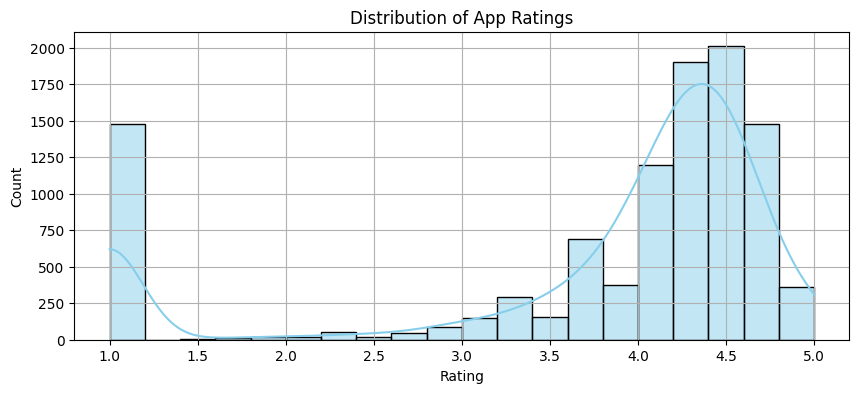

In [57]:
# Plot histogram with KDE for app Ratings
plt.figure(figsize=(10, 4))
sns.histplot(play_store_data['Rating'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of App Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.grid(True)
plt.show()

##### 1. Why did you pick the specific chart?

 A histogram with KDE is chosen to show the overall distribution of app ratings. It helps identify how ratings are spread (e.g., skewed, normal), where most apps cluster, and if any unusual patterns or outliers exist.

##### 2. What is/are the insight(s) found from the chart?

* The plot shows a concentration of apps with ratings in the 4 to 4.5 range indicating that the majority of apps on the Google Play Store are well-received by users
* The KDE plot (the smooth curve overlaying the histogram) shows a slight left skew suggesting that there are more apps with slightly lower ratings than apps with very high ratings.
* Notably, ratings of 1.0 might represent users who didn't provide feedback and could be considered neutral rather.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* To create positive business developers can spot apps with low ratings and work on fixing bugs or improving features to boost user satisfaction. This can be attained by studying highly-rated apps, identifying features users love and try to include similar ones.
* Only thing that could lead to negative growth is when developers ignore the insights and fail to address issues that lead to low ratings, it could negatively impact their app's success and user satisfaction resulting decreased downloads, negative reviews.

#### Do Paid Apps Get Better Ratings?

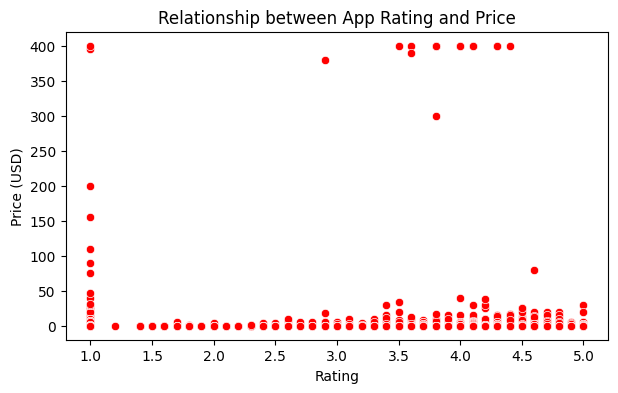

In [58]:
# Scatter plot to show relationship between app Rating and Price
plt.figure(figsize = (7,4))
sns.scatterplot(x = 'Rating', y = 'Price', data = play_store_data, color = 'red')
plt.title('Relationship between App Rating and Price')
plt.xlabel('Rating')
plt.ylabel('Price (USD)')
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is used here because it effectively shows the relationship between two continuous variables—app rating and price. It helps reveal trends, patterns, or correlations, such as whether higher prices lead to better ratings. The plot also makes it easy to spot outliers, like apps with unusually low ratings despite high prices. Since both variables are numerical and continuous, the scatter plot is a clear and simple way to interpret how price may influence user satisfaction.

##### 2. What is/are the insight(s) found from the chart?

* Free apps (Price = 0) show a wide range of ratings (2.5 to 4.5), indicating variability in quality among free apps.
* Paid apps generally have higher ratings (3.5 to 4.9), suggesting that paid apps might offer better quality or user satisfaction.
* High-priced apps (e.g., $9.99) can still achieve high ratings, indicating that price doesn’t necessarily deter users if the app delivers value.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Positive Business Impact: The insights might help developers with pricing strategies. For example, if there's a weak positive correlation between price and rating, it could suggest that users are willing to pay more for higher-quality apps.
* Negative Growth: If paid apps consistently receive lower ratings than free apps, it could discourage users from purchasing apps and impact developers' revenue.

#### Does App Size Impact User Ratings?

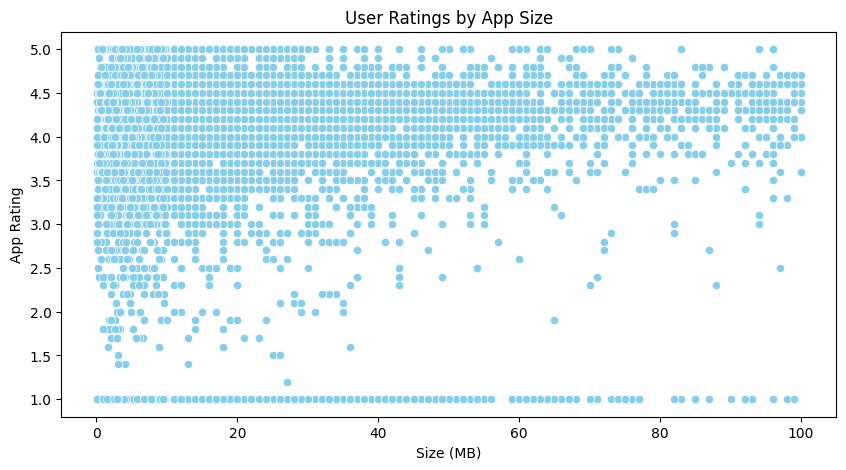

In [59]:
# Scatter plot to show the relationship between Rating and Size
plt.figure(figsize=(10, 5))
sns.scatterplot(x='Size', y='Rating', data=play_store_data, color='skyblue')
plt.title('User Ratings by App Size')
plt.xlabel('Size (MB)')
plt.ylabel('App Rating')
plt.show()

##### 1. Why did you pick the specific chart?

I chose a scatter plot to visualize the relationship between Rating and Size because it effectively shows patterns and variability between two numerical variables, highlighting how app size impacts ratings.

##### 2. What is/are the insight(s) found from the chart?

* Most apps are small (under 20 MB) and have high ratings, but ratings are spread across all sizes.
* There’s no strong correlation between app size and ratings. While some large apps get lower ratings, others achieve high ratings, suggesting that users care more about app quality than size alone.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Positive Business Impact: Developers can prioritize functionality over minimizing app size, as high ratings for larger apps (e.g., 50 MB, 4.7 rating) show users value quality, allowing for feature-rich apps without compromising user experience.
* Negative Growth: Large app sizes can deter users with limited storage, especially if quality doesn’t match the size (e.g., 70 MB, 3.9 rating), potentially leading to lower adoption rates and negative growth for larger apps with subpar performance.

#### Is Popularity Linked to Quality?

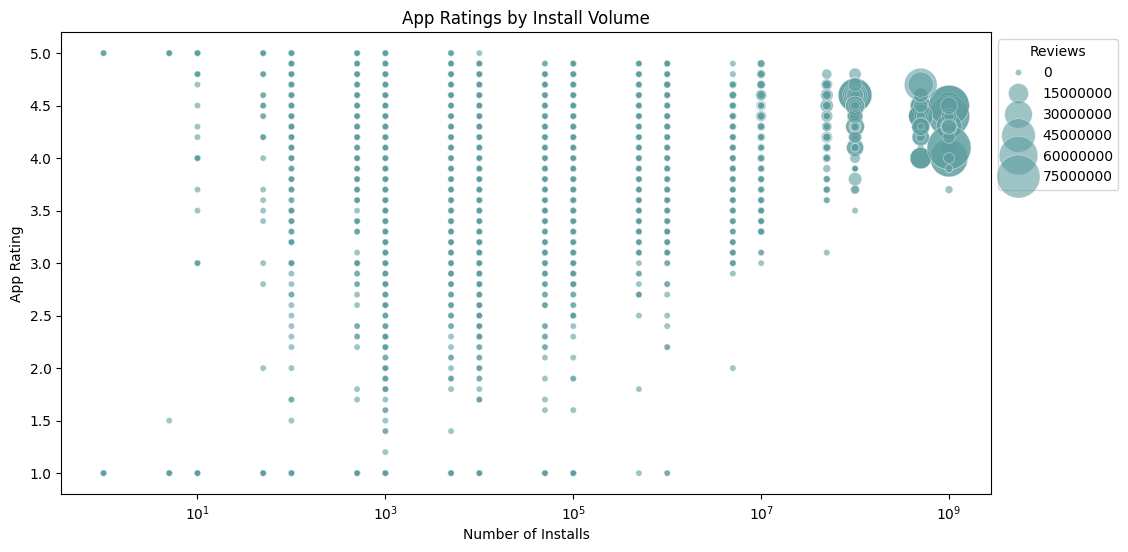

In [60]:
# Scatter plot to show the relationship between Rating and no. of Installs
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Installs', y='Rating', size='Reviews',sizes=(20, 1000), data=play_store_data, color='cadetblue', alpha=0.6)
plt.title('App Ratings by Install Volume')
plt.xlabel('Number of Installs')
plt.xscale('log')
plt.ylabel('App Rating')
plt.legend(title='Reviews', loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

##### 1. Why did you pick the specific chart?

I chose a scatter plot with a logarithmic X-axis to visualize the relationship between Rating and Installs, as it handles the wide range of Installs (1,000 to 50M) and shows patterns between two numerical variables.

##### 2. What is/are the insight(s) found from the chart?

There appears to be a weak positive correlation between the number of installs and the app rating. This suggests that apps with a higher number of installs tend to have slightly higher ratings, possibly indicating that more popular apps are generally better received by users.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Positive Business Impact: High ratings for apps with many installs (e.g., 50M installs, 4.6 rating) suggest focusing on quality can boost adoption and revenue.
* Negative Growth: Low ratings with fewer installs (e.g., 1,000 installs, 3.5 rating) may limit growth, leading to stagnation if quality isn’t improved.

#### Which App Categories Dominate the Play Store?

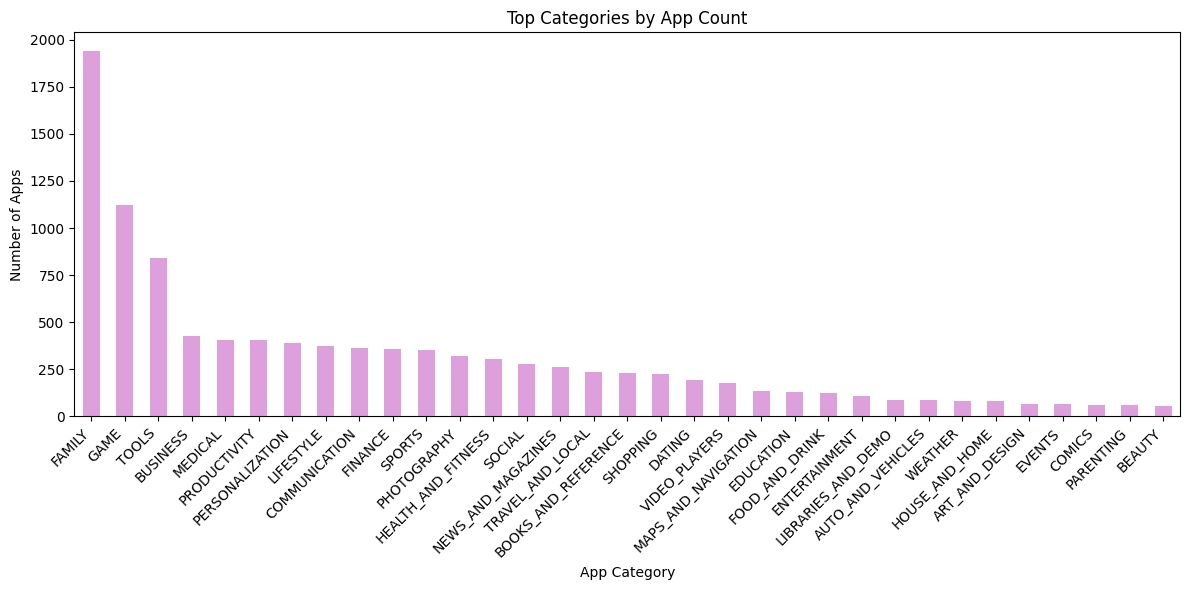

In [61]:
# Bar Plot for showing the distribution of app categories
plt.figure(figsize=(12, 6))
category_counts = play_store_data['Category'].value_counts().sort_values(ascending=False)
category_counts.plot(kind='bar', color='plum')
plt.title('Top Categories by App Count')
plt.xlabel('App Category')
plt.ylabel('Number of Apps')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is perfect for showing category-wise comparisons, here it clearly displays the number of apps per category.

##### 2. What is/are the insight(s) found from the chart?

* FAMILY has the most apps.

* GAME and TOOLS are also dominant.

* BEAUTY, PARENTING, and COMICS have the fewest apps.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Positive Business Impact: Developers can use this information to identify popular app categories and target their app development efforts accordingly.
* Negative Growth: Categories with fewer apps might represent niche markets or areas with less user interest, potentially leading to challenges in gaining traction and achieving significant growth.

####  How Extreme Are User Opinions?

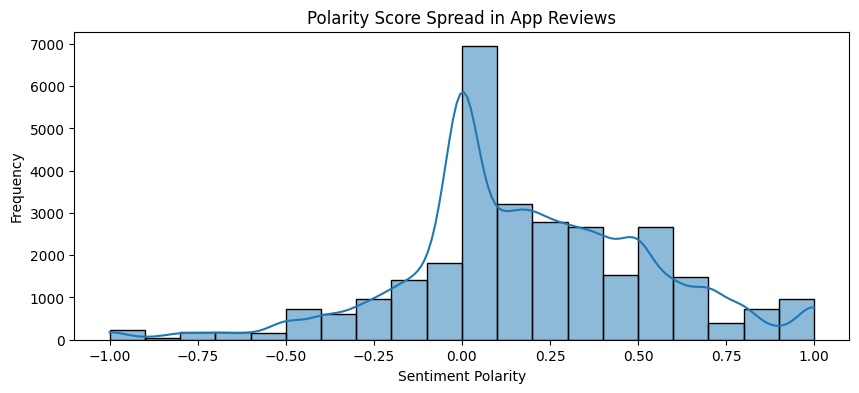

In [62]:
# Histogram plot for Sentiment Analysis
plt.figure(figsize=(10, 4))
sns.histplot(user_reviews_data['Sentiment_Polarity'], bins=20, kde=True)
plt.title('Polarity Score Spread in App Reviews')
plt.xlabel('Sentiment Polarity')
plt.ylabel('Frequency')
plt.show()


##### 1. Why did you pick the specific chart?

A histogram is suitable for visualizing the distribution of sentiment polarity scores, which are numerical values representing the sentiment expressed in user reviews. It shows the frequency of positive, neutral, and negative sentiments.

##### 2. What is/are the insight(s) found from the chart?

* Most reviews have neutral (around 0) or slightly positive sentiment.

* Very few extreme negative (-1) or highly positive (+1) reviews.

* Sentiment is slightly right-skewed (more positive than negative).



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Positive business impact: This analysis helps developers understand the overall sentiment towards their app and the specific features or aspects that are driving positive or negative feedback. By focusing on addressing negative feedback and enhancing positive features, developers can improve user satisfaction and app ratings.
* Negative Growth: There's a noticeable portion of reviews with negative sentiment polarity scores (below 0). These negative reviews could indicate areas where the app is not meeting user expectations or where there are usability issues. If these negative sentiments are not addressed, they could lead to negative growth through lower ratings, reduced user engagement, and negative word-of-mouth.

#### Do Happier Reviews Mean Higher Ratings?

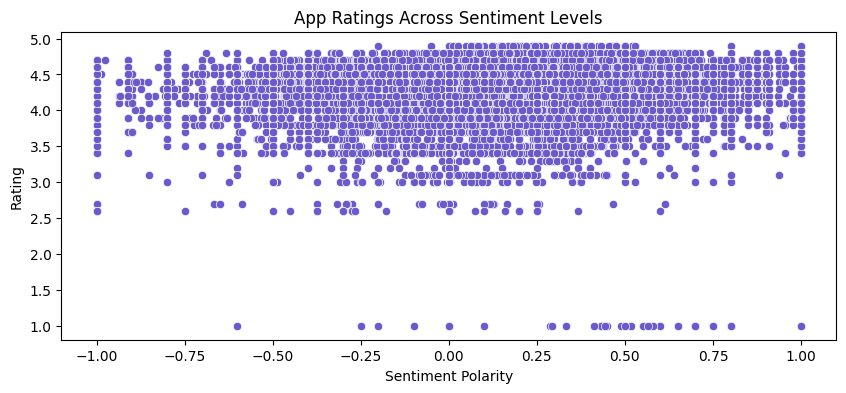

In [63]:
# Scatter Plot to understand the correlation between Sentiment Scores and App Ratings
plt.figure(figsize=(10, 4))
sns.scatterplot(x='Sentiment_Polarity', y='Rating', data=data, color = '#6a5acd')
plt.title('App Ratings Across Sentiment Levels')
plt.xlabel('Sentiment Polarity')
plt.ylabel('Rating')
plt.show()

##### 1. Why did you pick the specific chart?

 A scatter plot is used to explore the correlation between sentiment polarity and app ratings. It helps us see if apps with more positive sentiments tend to have higher ratings.

##### 2. What is/are the insight(s) found from the chart?

* There is a positive correlation between sentiment scores and app ratings. Apps with higher sentiment polarity scores tend to have higher ratings, suggesting that user sentiment is a strong indicator of app quality and user satisfaction.
* Most points are clustered around rating 4 and 5 across the sentiment spectrum, showing users generally rate apps positively even if the text isn't strongly enthusiastic.



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Positive Business Impact: Developers can focus on features and improvements that enhance user experience and drive positive reviews, which in turn can lead to higher app ratings and better performance in the app store.
* Negative Growth: If sentiment stays negative, ratings drop, affecting app visibility and trust.

#### How Big Are Apps in Each Category?

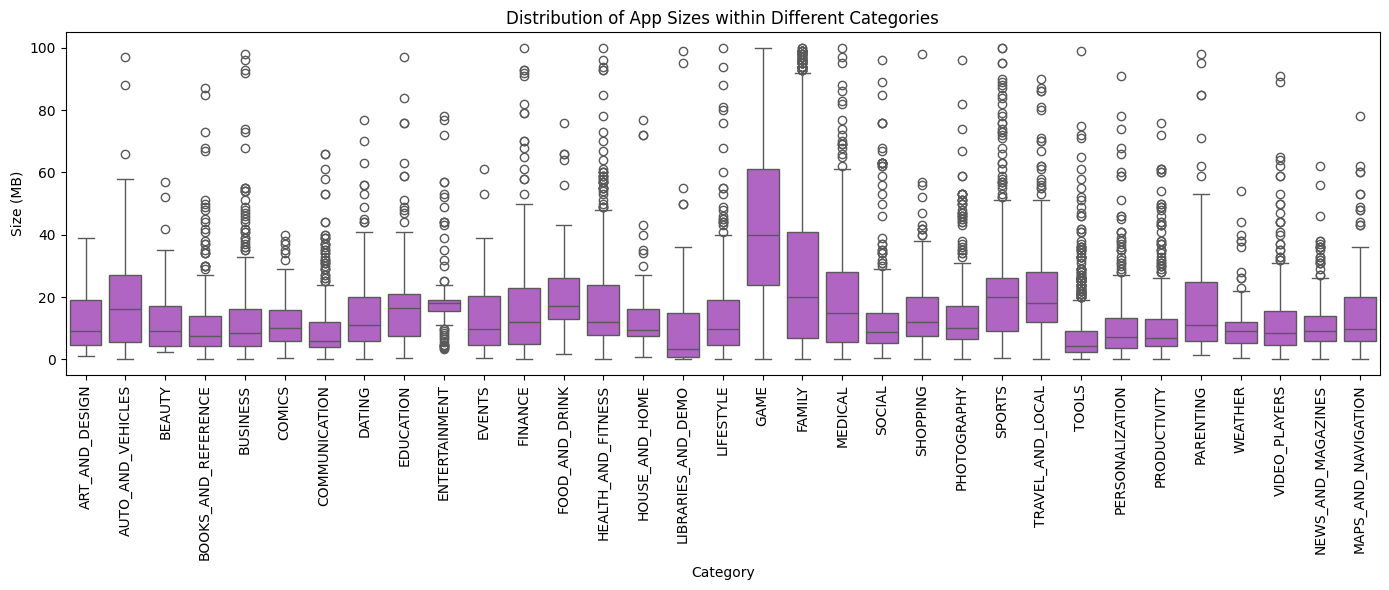

In [64]:
# Box Plot to visualize distribution of app size within different categories
plt.figure(figsize=(14, 6))
sns.boxplot(x='Category', y='Size', data=play_store_data, color= 'mediumorchid')
plt.title('Distribution of App Sizes within Different Categories')
plt.xlabel('Category')
plt.ylabel('Size (MB)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

This box plot is used because it clearly shows how app sizes vary across categories, including medians, ranges, and extreme outliers.

##### 2. What is/are the insight(s) found from the chart?

* GAME and FAMILY apps are generally the largest, likely due to heavy media content.

* TOOLS, MEDICAL, and BOOKS apps are smaller, focusing more on functionality than visuals.

* Several categories show outliers, meaning some apps are unusually large compared to others in the same group.



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Positive Business Impact: Developers can optimize their app sizes based on category norms and user expectations. For example, if a developer is creating a 'COMMUNICATION' app, they might aim for a smaller size to align with user expectations in that category.
* Negative Growth: Yes, if an app's size is significantly larger than the typical size for its category, it could lead to negative user perception and potentially lower ratings. Users might be hesitant to download or update large apps, especially if they have limited storage space on their devices. This could hinder app adoption and potentially lead to negative growth.

#### Paid vs Free Apps: What’s More Common?

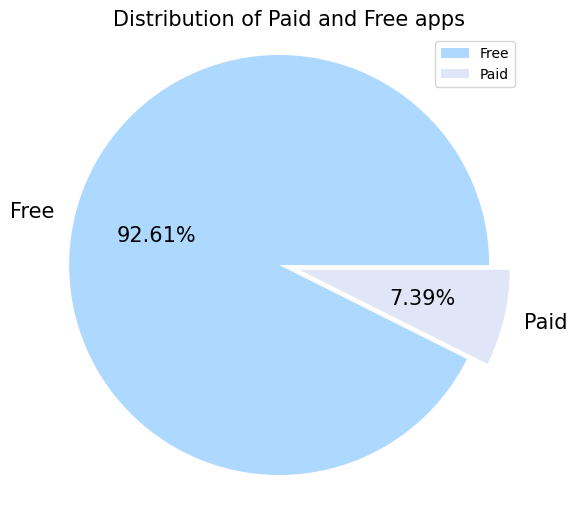

In [65]:
# Pie Chart to identify the ratio of paid apps w.r.t free apps
type_counts = play_store_data['Type'].value_counts()  # Store value counts in a separate variable
labels = type_counts.index  # Use index as labels
plt.figure(figsize=(6, 6))
colors = ["#ADD8FF", "#E0E6F8"]
explode = [0, 0.1]
plt.pie(type_counts, labels=labels, colors=colors, autopct='%.2f%%', explode=explode, textprops={'fontsize': 15})
plt.title('Distribution of Paid and Free apps', size=15, loc='center')
plt.legend()
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

##### 1. Why did you pick the specific chart?

A pie chart was chosen because it clearly shows the proportion between two categories — paid and free apps. It’s ideal for visualizing percentage-based comparisons at a glance.

##### 2. What is/are the insight(s) found from the chart?

Around 92.61% are free, and only 7.39% are paid showing that free apps dominate the market. Most developers opt for a free model, likely monetized through ads or in-app purchases.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Positive Business Impact: If launching a new app, consider starting with a free version to reach more users, then explore monetization options like premium or ads.

#### Top 10 Highest-Earning Paid Apps on Google Play Store

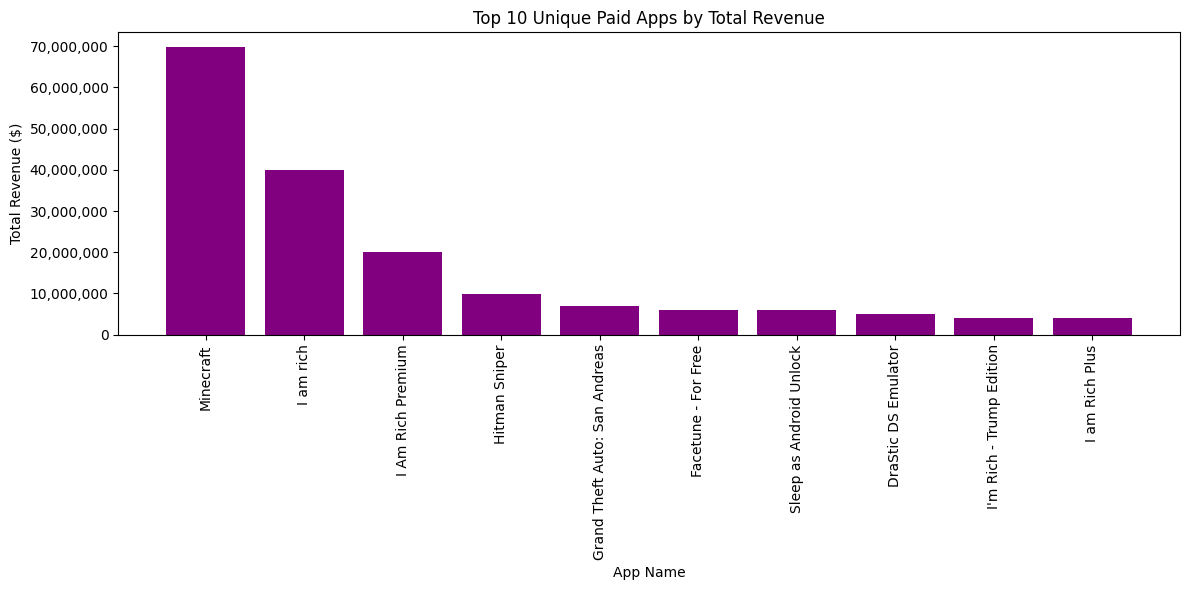

In [66]:
# Filter paid apps
paid_apps = play_store_data[play_store_data['Type'] == 'Paid'].copy()

# Calculate total revenue
paid_apps['Total_Revenue'] = paid_apps['Price'] * paid_apps['Installs']

# Drop duplicate app names (keep highest revenue entry)
paid_apps_unique = paid_apps.sort_values(by='Total_Revenue', ascending=False).drop_duplicates(subset='App')

# Get top 10 unique apps
top10 = paid_apps_unique.head(10).reset_index(drop=True)

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(top10['App'], top10['Total_Revenue'], color='purple')
ax.set_title('Top 10 Unique Paid Apps by Total Revenue')
ax.set_xlabel('App Name')
ax.set_ylabel('Total Revenue ($)')
ax.set_xticks(range(len(top10)))
ax.set_xticklabels(top10['App'], rotation=90)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

It clearly shows revenue comparison among top unique paid apps using a simple bar chart—easy to read and compare.

##### 2. What is/are the insight(s) found from the chart?

* Minecraft dominates with the highest revenue.

* Multiple “I Am Rich”-type novelty apps make surprising revenue.

* Popular games and utility apps also perform well.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Positive Impact: Shows that premium apps can generate massive revenue, especially games or unique niche apps.

* Negative Growth: High revenue from joke apps (like “I Am Rich”) may hurt store reputation and user trust if overused. Its a short-term profit with possible backlash

#### Which Categories Get Better Ratings?

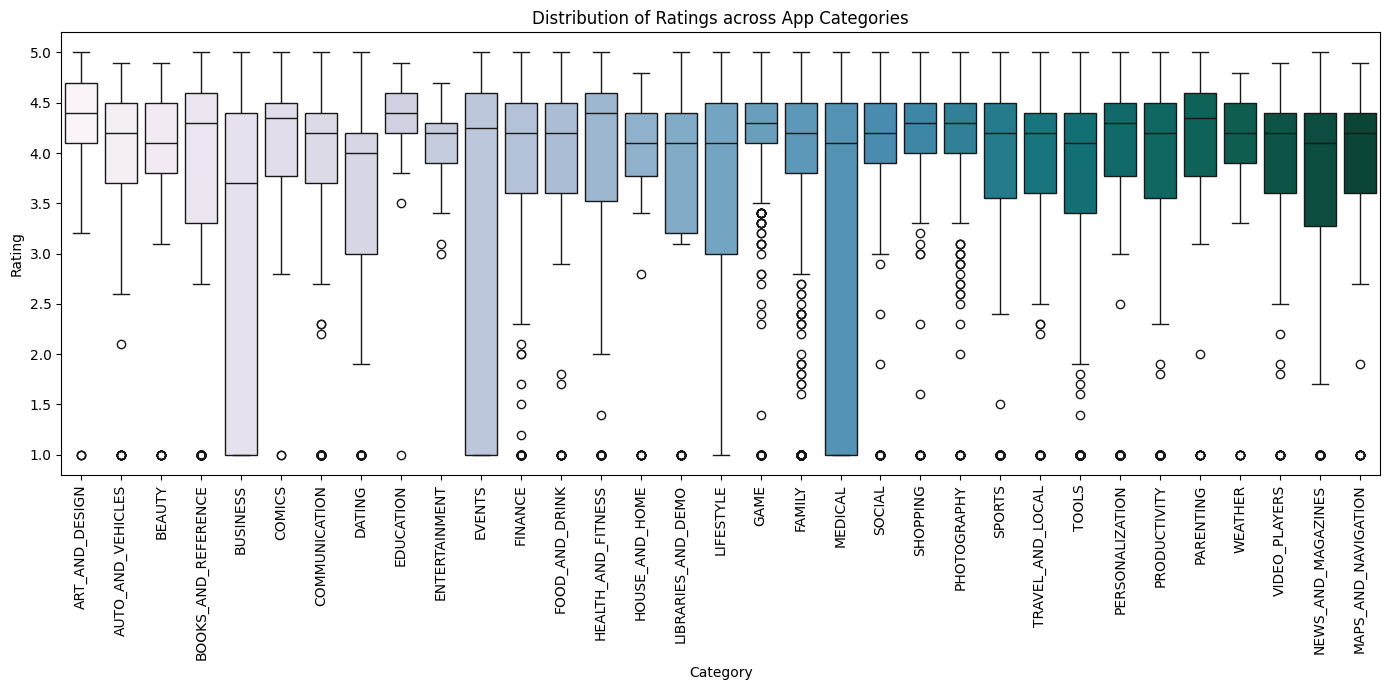

In [67]:
# Box plot: Ratings within Categories
plt.figure(figsize=(14, 7))
sns.boxplot(x='Category', y='Rating', data=play_store_data, palette= 'PuBuGn', hue = 'Category')
plt.title('Distribution of Ratings across App Categories')
plt.xlabel('Category')
plt.xticks(rotation=90)
plt.ylabel('Rating')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Box plots clearly show rating distribution and outliers across categories, helping compare app quality visually.

##### 2. What is/are the insight(s) found from the chart?

* Categories like ART_AND_DESIGN, PARENTING, and BOOKS_AND_REFERENCE have consistently high median ratings, meaning users are generally satisfied.

* MEDICAL, EVENTS, and BUSINESS categories have many outliers and low medians, indicating poor performance or inconsistent app quality.

* High variance in GAME and FAMILY suggests uneven quality—some apps do well, others don’t.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Positive: Categories with high and stable ratings show strong user trust—ideal for investment, promotions, or feature expansion.

* Negative: Low-performing categories like MEDICAL or EVENTS may damage brand perception if not improved. Poor ratings can reduce user retention and app store visibility.

#### Is Popularity Driving Feedback?

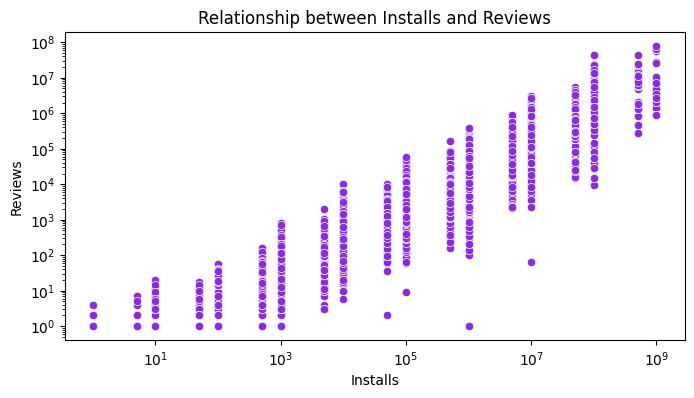

In [68]:
# Scatter plot indicating correlation of Installs with Reviews
plt.figure(figsize=(8, 4))
sns.scatterplot(x='Installs', y='Reviews', data=play_store_data, color='#8A2BE2')
plt.title('Relationship between Installs and Reviews')
plt.xlabel('Installs')
plt.xscale('log')
plt.ylabel('Reviews')
plt.yscale('log')
plt.show()

##### 1. Why did you pick the specific chart?

In this case, 'Installs' and 'Reviews'are two numerical values so, this plot helps identify patterns, trends, and potential correlations between the variables.

##### 2. What is/are the insight(s) found from the chart?

The scatter plot shows a positive correlation between installs and reviews. Apps with higher installs tend to have more reviews, indicating that popular apps generally receive more user feedback.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this insight can help create a positive business impact. By focusing on increasing app installs, developers can expect a corresponding increase in user reviews, which can further enhance the app's visibility and credibility. There are no insights that directly lead to negative growth, but neglecting user reviews despite high installs could potentially harm the app's reputation.

#### How Average App Ratings Have Evolved?

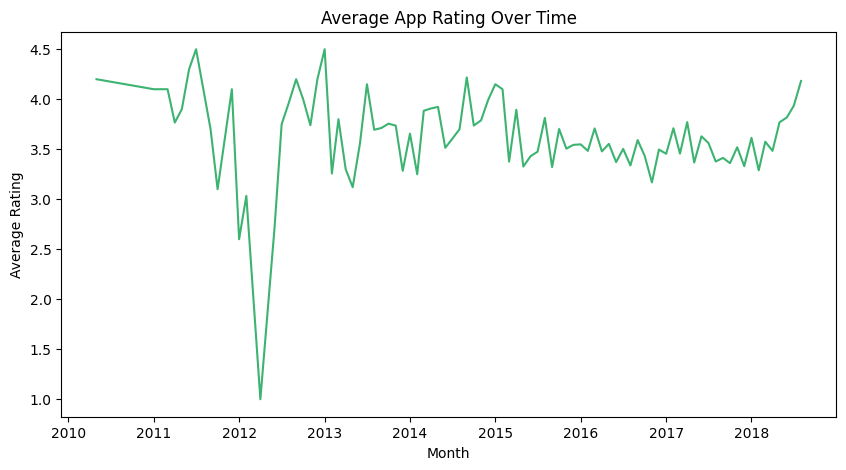

In [69]:
# Extract year and month as separate columns
play_store_data['Year'] = play_store_data['Last Updated'].dt.year
play_store_data['Month'] = play_store_data['Last Updated'].dt.month

# Group by Year and Month to get average rating
monthly_ratings = play_store_data.groupby(['Year', 'Month'])['Rating'].mean().reset_index()

# Create a new datetime column for plotting
monthly_ratings['Date'] = pd.to_datetime(monthly_ratings[['Year', 'Month']].assign(DAY=1))

# Line Plot
plt.figure(figsize=(10, 5))
sns.lineplot(x='Date', y='Rating', data=monthly_ratings, color='#3CB371')
plt.title('Average App Rating Over Time')
plt.xlabel('Month')
plt.ylabel('Average Rating')
plt.show()

##### 1. Why did you pick the specific chart?

A line chart effectively shows how average app ratings change over time, making trends and anomalies easy to spot.

##### 2. What is/are the insight(s) found from the chart?

* Ratings were stable from 2010 to 2011, then saw a sharp drop in 2012 (below 2).

* Quick recovery followed, but fluctuations continued till 2014.

* From 2015–2018, ratings were more stable around 3.5 to 4, with a rise at the end.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Positive Business Impact: The upward trend post-2012 shows improved app quality and user satisfaction—good for brand trust.
* Negative Growth Insight: The 2012 dip may indicate poor app releases or major bugs, causing temporary negative growth. Understanding this can help avoid future rating crashes.

#### Heavy Feedback, High Ratings?

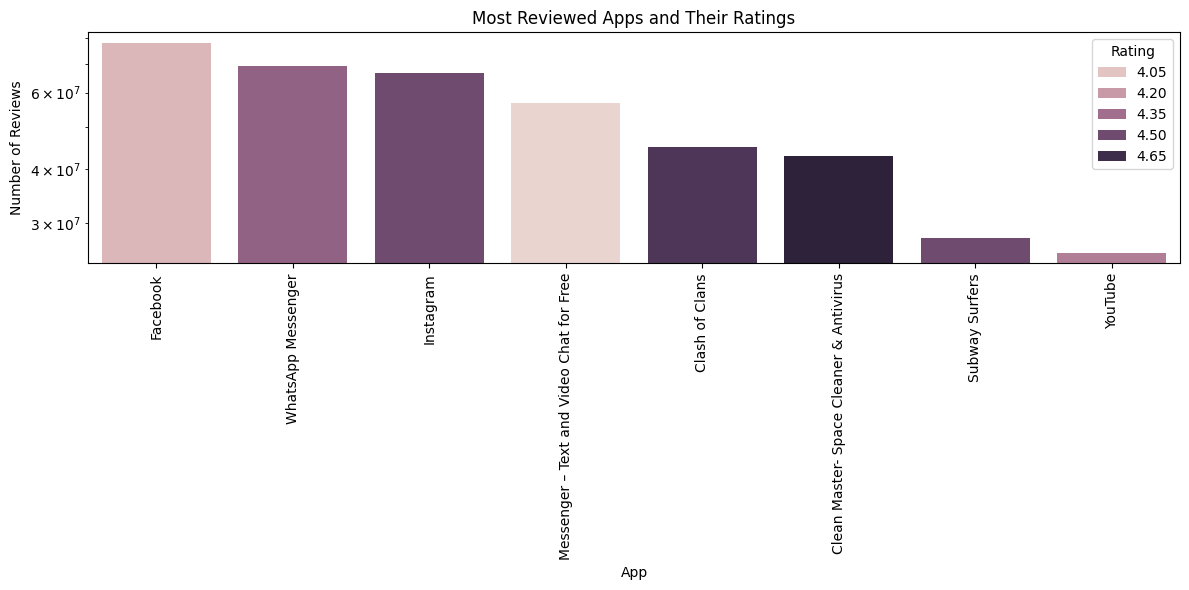

In [70]:
# Bar chart with color coded Ratings
most_reviewed_apps = play_store_data.sort_values(by='Reviews', ascending=False).head(20)
plt.figure(figsize=(12, 6))
sns.barplot(x='App', y='Reviews', data=most_reviewed_apps, hue='Rating')
plt.xticks(rotation = 90)
plt.title('Most Reviewed Apps and Their Ratings')
plt.xlabel('App')
plt.ylabel('Number of Reviews')
plt.yscale('log')
plt.legend(title='Rating')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart with color encoding shows both review volume and average rating together, making it easy to compare top apps.

##### 2. What is/are the insight(s) found from the chart?

* Facebook has the highest number of reviews, but lower rating (≈4.05).

* Apps like Clean Master and Clash of Clans have fewer reviews but higher ratings (≈4.65).

* YouTube, despite its popularity, has lowest review count and rating among top apps.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Positive Business Impact: High-rated apps with fewer reviews (e.g., Clean Master) show strong user satisfaction, good for long-term growth.

* Negative Growth: Apps like Facebook with many users but lower ratings may face reputation issues, leading to user churn if not improved.

#### Downloads High, Ratings Higher?

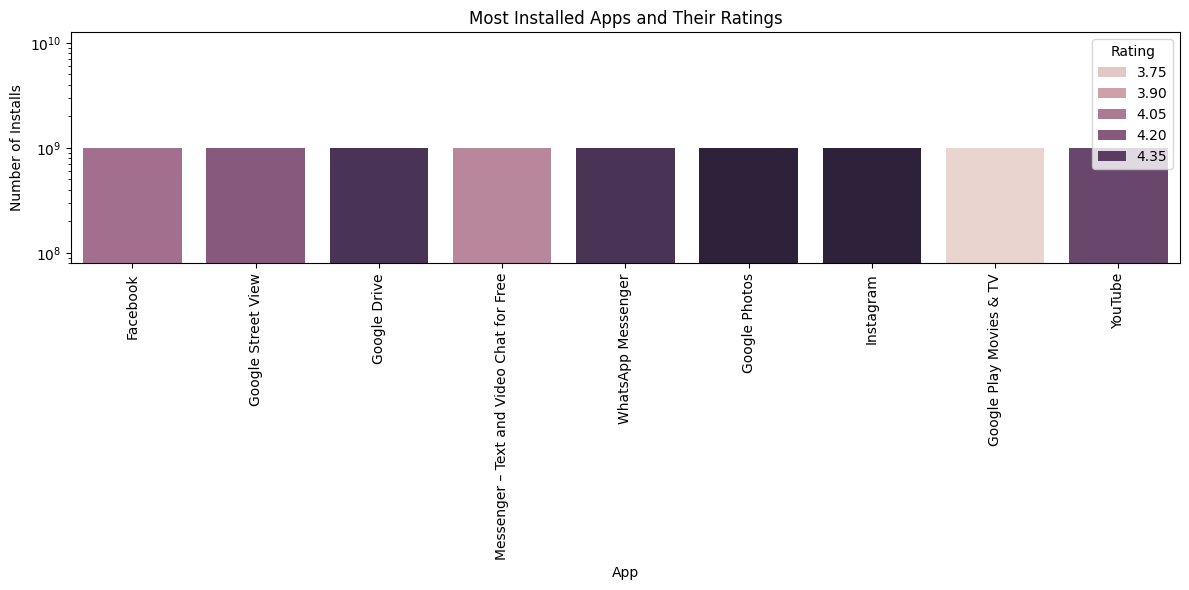

In [71]:
# Bar chart to visualize most Installed or popular apps with their Ratings
most_installed_apps = play_store_data.sort_values(by='Installs', ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x='App', y='Installs', data=most_installed_apps, hue='Rating')
plt.xticks(rotation = 90)
plt.title('Most Installed Apps and Their Ratings')
plt.xlabel('App')
plt.ylabel('Number of Installs')
plt.yscale('log')
plt.legend(title='Rating')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart clearly shows both app popularity (install count) and user satisfaction (ratings) in one view, making it easy to analyze and compare.

##### 2. What is/are the insight(s) found from the chart?

All apps have high installs, but ratings vary. Apps like Subway Surfers and Google Photos have high ratings, while Google News and Hangouts have low ratings, indicating possible user dissatisfaction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Positive Business Impact: The insights help identify which apps are doing well and which need improvement, guiding better product decisions and enhancing user experience.

* Negative Growth: Lo+
-rated apps like Google News and Hangouts may face user drop-off or poor engagement if issues aren’t addressed, which can harm the brand.

#### Do Regular Updates Keep Ratings High?

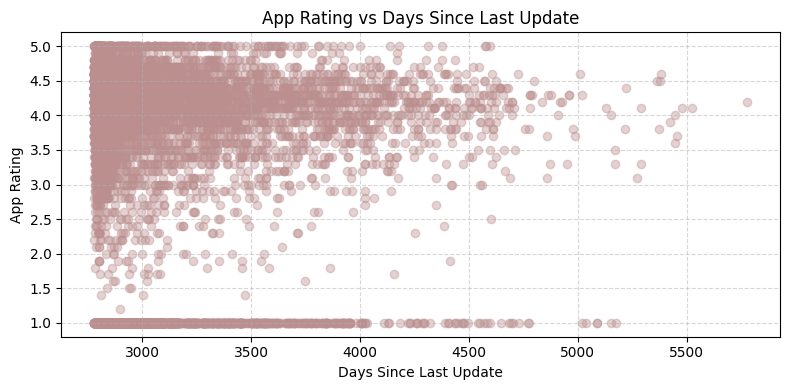

In [72]:
# Calculate days since last update
today = pd.to_datetime('today')
play_store_data['Days Since Update'] = (today - play_store_data['Last Updated']).dt.days

# Scatter plot: Days since update vs Rating
plt.figure(figsize=(8,4))
plt.scatter(play_store_data['Days Since Update'], play_store_data['Rating'], alpha=0.4, color='#BC8F8F')
plt.xlabel('Days Since Last Update')
plt.ylabel('App Rating')
plt.title('App Rating vs Days Since Last Update')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is ideal for showing the relationship between update frequency and user ratings. It clearly visualizes how delays in app updates may correlate with lower ratings.



##### 2. What is/are the insight(s) found from the chart?

* Newer apps (lower days) tend to have a wider range of high ratings (3.5–5.0).

* As apps get older (higher days) without updates, ratings drop, many clustering around 1.0–3.0.

* Apps that haven’t been updated in a long time often suffer from low user ratings.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Positive Impact: It highlights the importance of timely updates. Developers can use this to schedule regular updates, which may lead to higher user satisfaction and better app store performance.
* Negative Growth: The chart shows that apps not updated for long periods tend to have lower ratings. This indicates neglect or outdated features, leading to user dissatisfaction and possible uninstalls — directly harming growth.

#### Correlation Matrix Heatmap

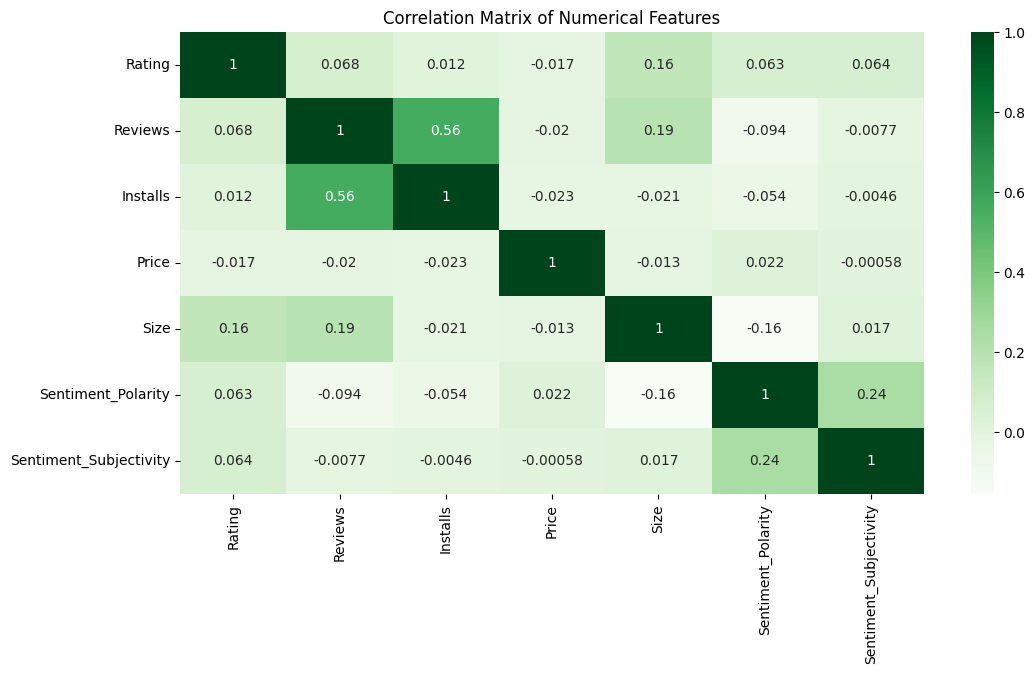

In [73]:
numerical_cols = ['Rating', 'Reviews', 'Installs', 'Price', 'Size', 'Sentiment_Polarity', 'Sentiment_Subjectivity']
correlation_matrix = data[numerical_cols].corr()

plt.figure(figsize=(12, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='Greens')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

##### 1. Why did you pick the specific chart?

A heatmap is a good way to visualize the correlation between multiple numerical variables. It shows the strength and direction of the relationships, helping us identify potential dependencies and patterns in the data.

##### 2. What is/are the insight(s) found from the chart?

* There is a strong positive correlation between 'Reviews' and 'Installs', indicating that more popular apps tend to have more reviews.
* Sentiment Polarity & Subjectivity also correlate moderately.
* Price has almost no correlation with any feature.
* Ratings have weak or no strong correlation with other variables.
* Larger apps tend to get slightly more reviews, possibly because they offer more features or are more engaging. However, the connection isn’t strong.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Positive Business Impact: Developers can use this to understand which factors are most strongly correlated with app success and prioritize their efforts accordingly. For example, focusing on getting more reviews can boost installs.
* Negative Growth: Relying on price to influence other metrics won't help as price doesn't impact much. Also, Bigger size alone doesn’t guarantee more reviews as content matters more.

#### Pair Plot

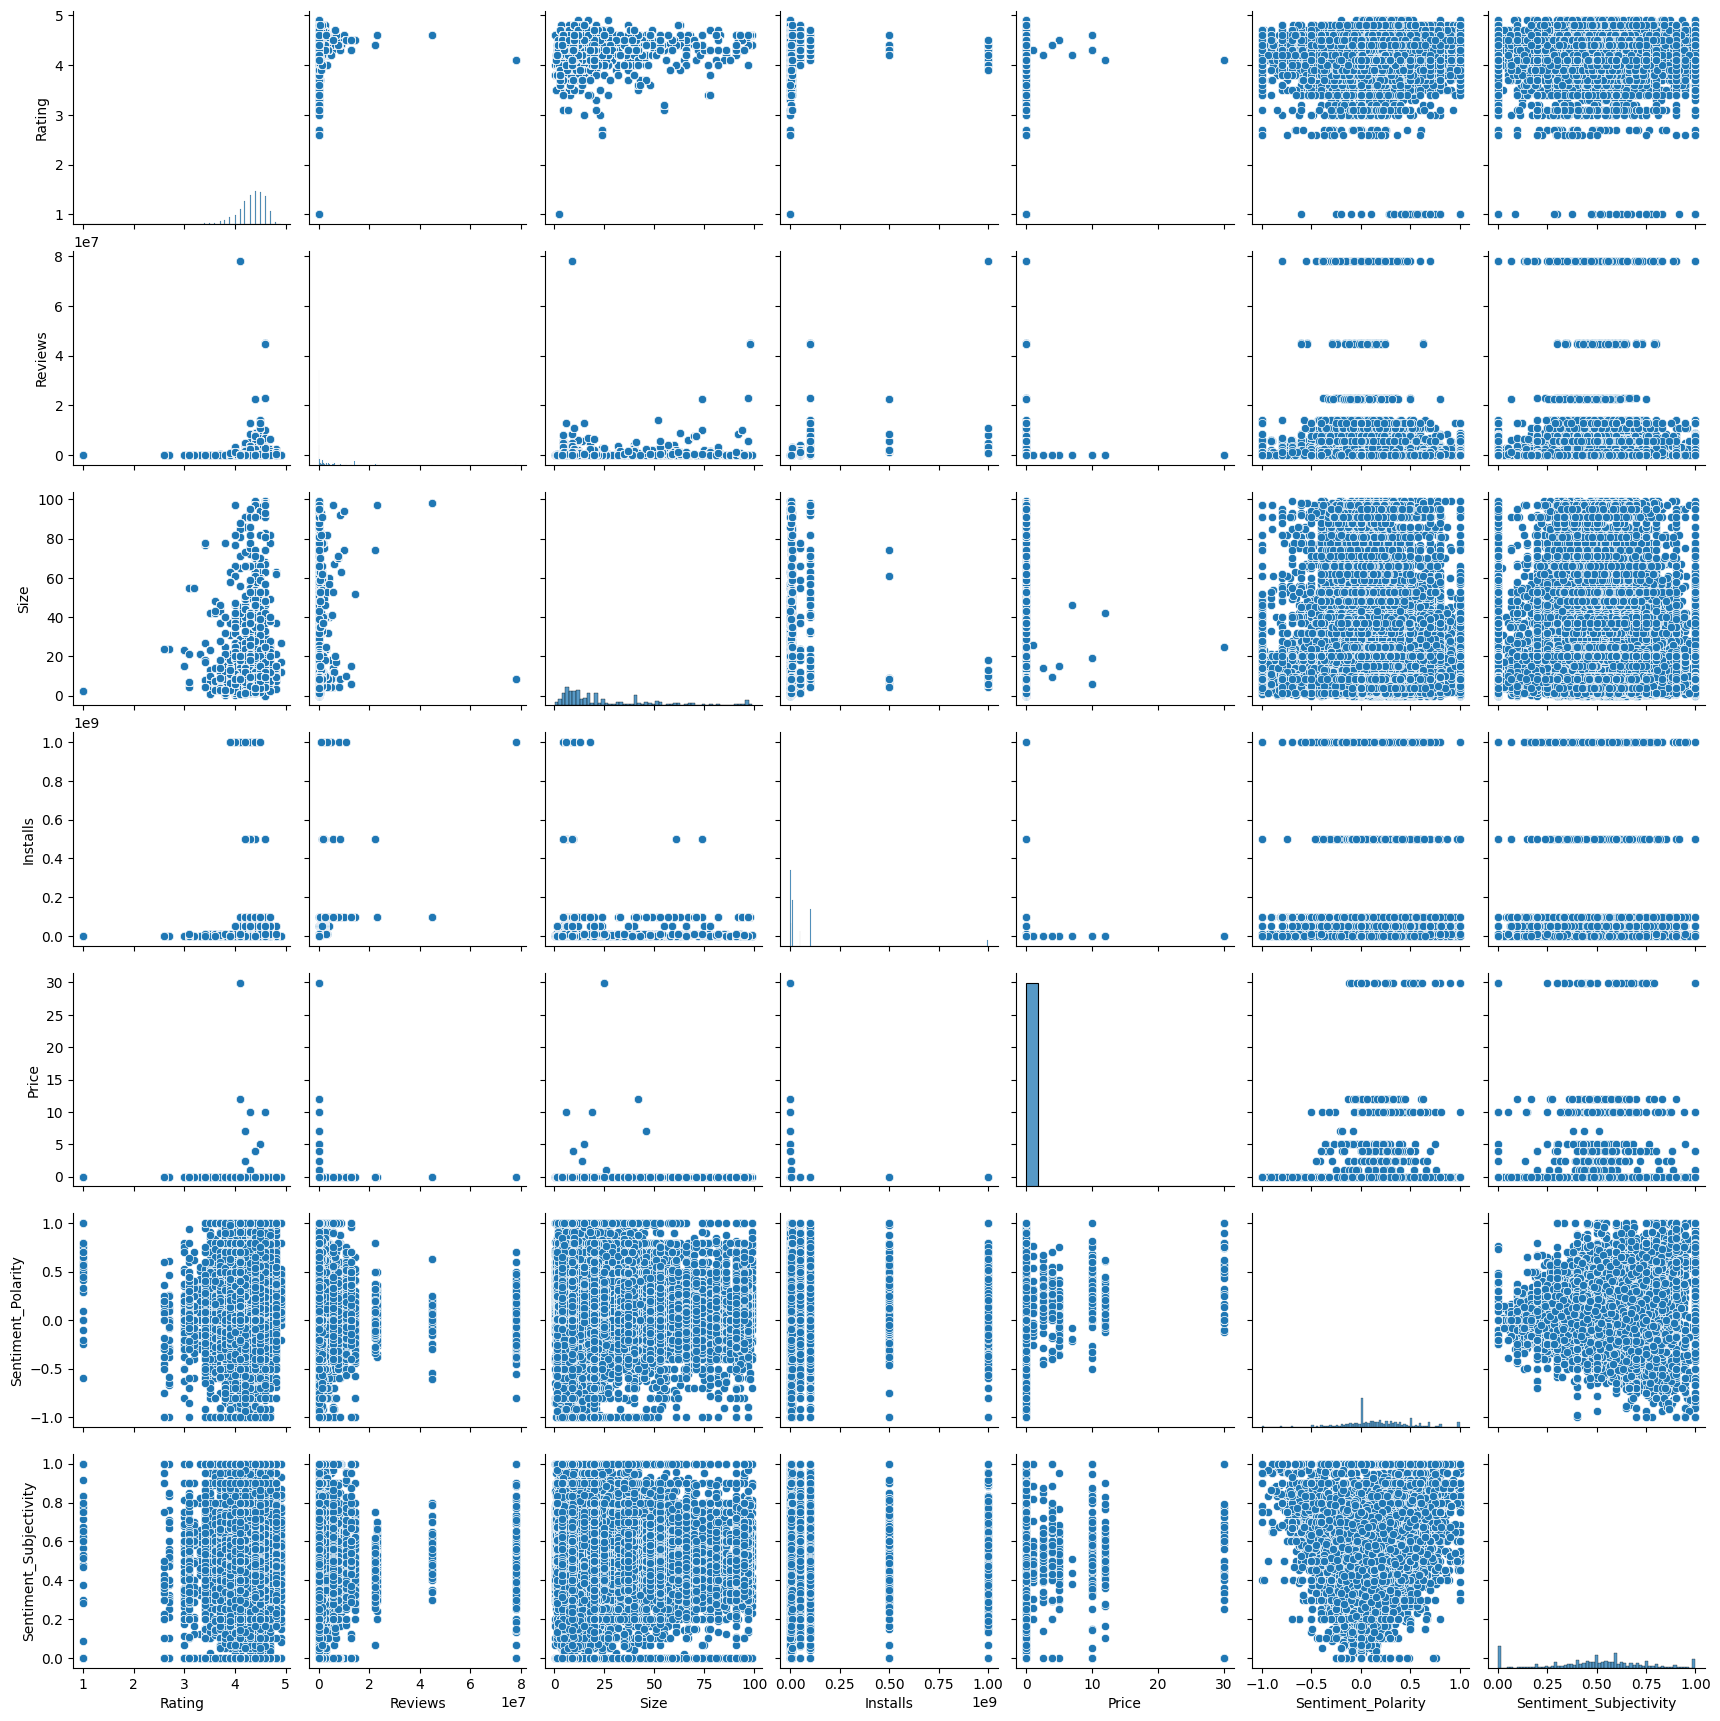

In [74]:
# Pair Plot visualization code
sns.pairplot(data)
plt.show()

##### 1. Why did you pick the specific chart?

Visualizes relationships between multiple variables through scatter plots and histograms. Useful for identifying correlations, distributions, and outliers across all variables.

##### 2. What is/are the insight(s) found from the chart?

* The diagonal histograms show the distribution of each numerical variable (Rating, Reviews, Size, Installs, Price, Sentiment_Polarity, Sentiment_Subjectivity).
* The scatter plots off the diagonal visualize the relationships between pairs of numerical variables.
* We can observe the spread and potential outliers in each numerical column.
Some plots show apparent clusters or patterns, while others appear more scattered, suggesting varying degrees of correlation between the variables.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Positive Impact: Identifying correlations between variables can inform decision-making. This insight could guide app development strategies.
* Negative Growth: If the pair plot reveals negative correlations where positive ones would be expected, it highlights areas where the app's performance might be negatively impacted.

#### Sentiment Analysis

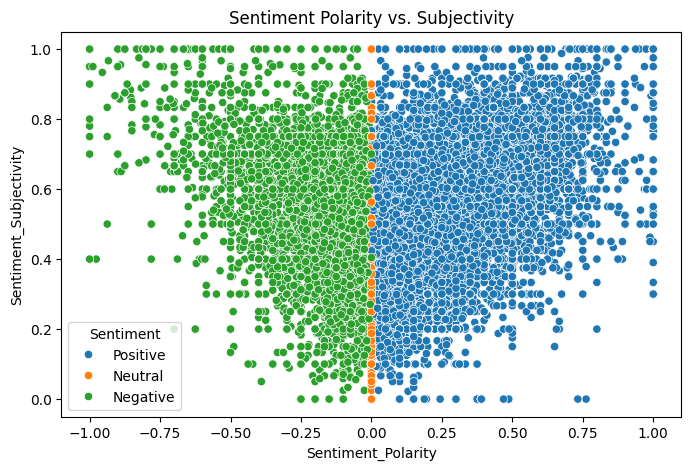

In [75]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Sentiment_Polarity', y='Sentiment_Subjectivity', hue='Sentiment', data=user_reviews_data)
plt.title('Sentiment Polarity vs. Subjectivity')
plt.show()

##### 1. Why did you pick the specific chart?

This would help to observe how different sentiment categories (positive, negative, neutral) are distributed across the polarity and subjectivity ranges.

##### 2. What is/are the insight(s) found from the chart?

* Positive reviews tend to have higher sentiment polarity (closer to 1) and a wider range of subjectivity.
* Negative reviews tend to have lower sentiment polarity (closer to -1) and also show a range of subjectivity.
* Neutral reviews are clustered around a sentiment polarity of 0 and generally lower subjectivity.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Positive Impact: Understanding the distribution of sentiments helps identify areas for improvement. For example, a high number of negative reviews clustered in a certain area of the plot might indicate specific issues that need addressing, leading to positive impact if fixed.
* Negative Growth: A large cluster of negative sentiment reviews with low subjectivity could indicate specific, concrete problems that users are experiencing. Ignoring these could lead to negative growth as more users encounter the same issues and leave negative feedback.

#### Visualize Sentiment Distribution

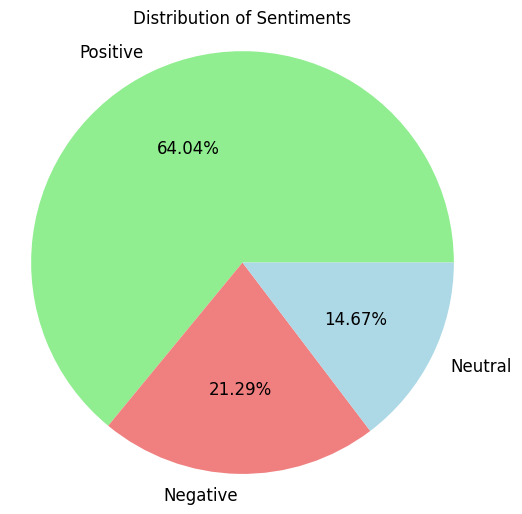

In [76]:
plt.figure(figsize=(6, 6))
sentiment_counts = user_reviews_data['Sentiment'].value_counts()
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.2f%%', colors=['lightgreen', 'lightcoral', 'lightblue'], textprops={'fontsize': 12})
plt.title('Distribution of Sentiments')
plt.axis('equal')
plt.show()

##### 1. Why did you pick the specific chart?

A pie chart is suitable for displaying the proportion of each sentiment category (positive, negative, neutral) relative to the whole.

##### 2. What is/are the insight(s) found from the chart?

* 64.04% of sentiments are positive, 21.29% are negative and 14.67% are neutral.

* Most users are happy, with a small portion expressing dissatisfaction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Positive Impact: High positive sentiment shows customer satisfaction. Can be used in marketing to build trust and brand loyalty.
* Negative Growth: 21.29% negative feedback is a concern. Ignoring it can lead to customer churn and bad reviews.

#### How Age Labels Affect App Ratings?

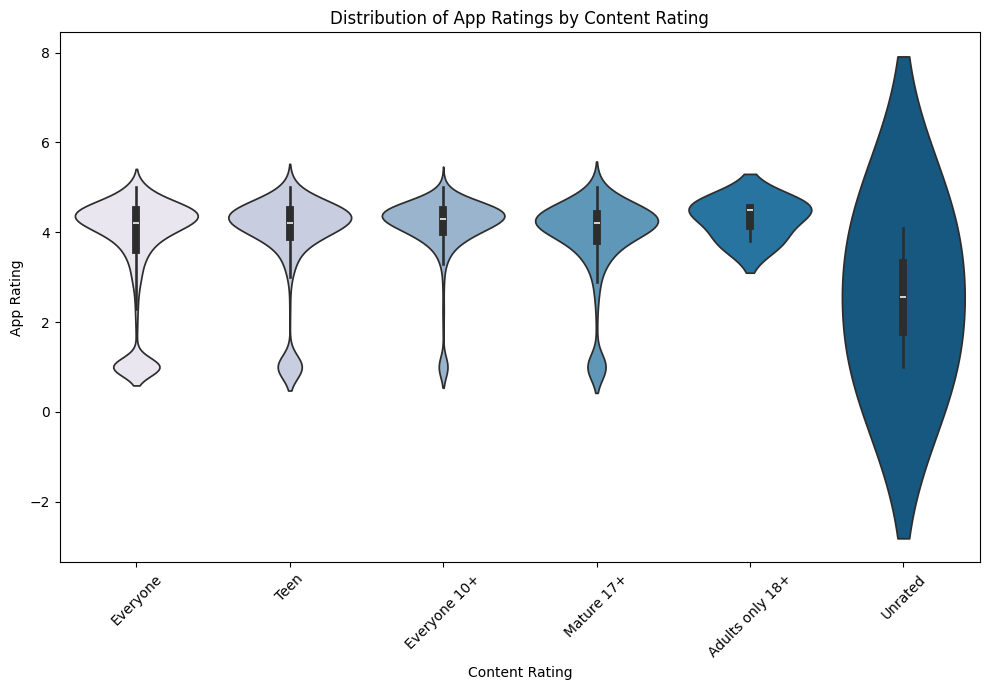

In [77]:
plt.figure(figsize=(10, 7))
sns.violinplot(x='Content Rating', y='Rating', data=play_store_data, hue='Content Rating', palette='PuBu', legend=False)
plt.title('Distribution of App Ratings by Content Rating')
plt.xlabel('Content Rating')
plt.ylabel('App Rating')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Violin chart shows distribution + density of app ratings, highlights variation within each content rating. Better than bar/box plots for spotting outliers and spread.

##### 2. What is/are the insight(s) found from the chart?

* Most content ratings have similar high app ratings (around 4+).

* "Adults only 18+" apps are few but rated high.

* Unrated apps show wide variation and lower average ratings.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Positive Impact: Targeting rated categories like “Everyone” or “Teen” is safer and gets better ratings. High ratings in “Adults only 18+” show niche potential.
* Negative Growth: “Unrated” apps have inconsistent and low ratings. Lack of trust and unclear content can push users away. Rating your app properly builds credibility.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

* **Focus on Free Apps with Monetization:**
Since over 90% of apps are free and dominate installs, developing free apps with ads or in-app purchases can maximize reach and user base growth.

* **Prioritize Regular Updates:**
Data shows apps with frequent updates maintain higher ratings. Encourage continuous app improvement and timely bug fixes to retain user trust and boost ratings.

* **Optimize App Size:**
Smaller apps tend to have better ratings and downloads. Keep the app lightweight to enhance user experience and attract more installs, especially in categories like Tools and Education.

* **Leverage Positive Sentiment and Reviews:**
Positive sentiment correlates with higher ratings. Use sentiment analysis to monitor user feedback, quickly address negative sentiments, and highlight strengths in marketing.

* **Target High-Install Categories (Family, Game, Tools):**
These categories have the highest installs and revenue potential. Focus development and marketing efforts here to tap into large, engaged user bases.

* **Balance Paid App Pricing and Quality:**
Although paid apps are fewer, those with clear value and moderate pricing perform well. Use pricing strategies aligned with user expectations and app quality.

* **Encourage User Reviews to Boost Visibility:**
Higher installs correlate with more reviews. Incentivize users to leave feedback, improving app visibility and social proof.

* **Monitor Content Ratings Closely:**
“Everyone” content rating dominates with high installs and ratings. Ensure apps target broad audiences and comply with content guidelines to maximize downloads.

# **Conclusion**

Exploring the Google Play Store data was like uncovering a treasure map to app success! 🗺️ Free apps rule the market 🌍, showing that easy access is the key to winning users’ hearts ❤️ and downloads 📲. But it’s not just about being free—quality matters! Apps that stay updated 🔄, stay light ⚖️, and listen to user feedback 💬 shine the brightest stars 🌟 in this crowded sky.

Sentiment analysis gave us the real pulse of users—mostly happy 😊, guiding developers on what works and what needs fixing 🔧. Popular categories like Family 👨‍👩‍👧‍👦, Games 🎮, and Tools 🛠️ offer huge opportunities, but competition is fierce ⚔️.

Paid apps may be the underdogs 🐾, but those who bring unique value 💎 can still rake in big rewards 💰.

For businesses aiming to conquer the Play Store, the formula is clear: focus on user experience 🎯, keep improving constantly 🔄, and let data be your compass 🧭. Follow this path, and your app could be the next big success story! 🚀✨